In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR    = r'D:\Tseng\圍棋\singletrials_timewindows'
BANDS       = ['Alpha', 'Beta', 'Delta', 'Gamma', 'Theta']
PARIETAL_CH = ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
GROUPS      = ['master', 'amateur', 'prof']
COLORS      = {'master': 'steelblue', 'amateur': 'darkorange', 'prof': 'forestgreen'}

time_vals = [x / 10 for x in range(5, 195, 5)]   # 0.5 ~ 19.0，共 38 個
TIME_COLS = []
for v in time_vals:
    int_part = int(v)
    dec_part = round((v - int_part) * 10)
    TIME_COLS.append(f'T_{int_part}_{dec_part}s')

# 只用 Alpha 取 Rate（各頻帶 Rate 相同）
df_raw = pd.read_csv(f'{DATA_DIR}\\Original_Alpha.csv')
df_raw['Rate'] = pd.to_numeric(df_raw['Rate'], errors='coerce')

# 每個 trial 去重
df_trials = (
    df_raw[df_raw['Channel'].isin(PARIETAL_CH)]
    .groupby(['Group', 'SubjectID', 'Session', 'Epoch'], as_index=False)['Rate']
    .first()
)

print('各 group trial 數：')
print(df_trials.groupby('Group').size())
print('\nRate NaN 數：', df_trials['Rate'].isna().sum())

各 group trial 數：
Group
amateur    2460
master     1857
prof        719
dtype: int64

Rate NaN 數： 151


In [2]:
# ── Rate 基本統計 ──
print('=== Rate 描述統計（%）===')
for g in GROUPS:
    r = df_trials[df_trials['Group'] == g]['Rate'].dropna()
    q1, med, q3 = r.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    print(f'\n[{g}]  N={len(r)}')
    print(f'  mean={r.mean():.2f}  std={r.std():.2f}  median={med:.2f}')
    print(f'  min={r.min():.2f}  max={r.max():.2f}')
    print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
    # Rate 是百分比，看看是否有超出 0~100 的值
    n_invalid = ((r < 0) | (r > 100)).sum()
    print(f'  超出 [0, 100] 的值：{n_invalid}')
    # 唯一值數量（如果 Rate 是 per-subject 固定值，唯一值會很少）
    print(f'  唯一值數量：{r.nunique()}  (若極少代表 Rate 是 subject-level 固定值)')

=== Rate 描述統計（%）===

[master]  N=1826
  mean=52.51  std=22.85  median=50.85
  min=0.20  max=99.40
  Q1=38.10  Q3=66.50  IQR=28.40
  超出 [0, 100] 的值：0
  唯一值數量：683  (若極少代表 Rate 是 subject-level 固定值)

[amateur]  N=2340
  mean=45.11  std=23.72  median=44.50
  min=0.10  max=99.40
  Q1=29.80  Q3=60.60  IQR=30.80
  超出 [0, 100] 的值：0
  唯一值數量：771  (若極少代表 Rate 是 subject-level 固定值)

[prof]  N=719
  mean=54.03  std=22.26  median=52.90
  min=0.30  max=99.40
  Q1=39.10  Q3=67.65  IQR=28.55
  超出 [0, 100] 的值：0
  唯一值數量：447  (若極少代表 Rate 是 subject-level 固定值)


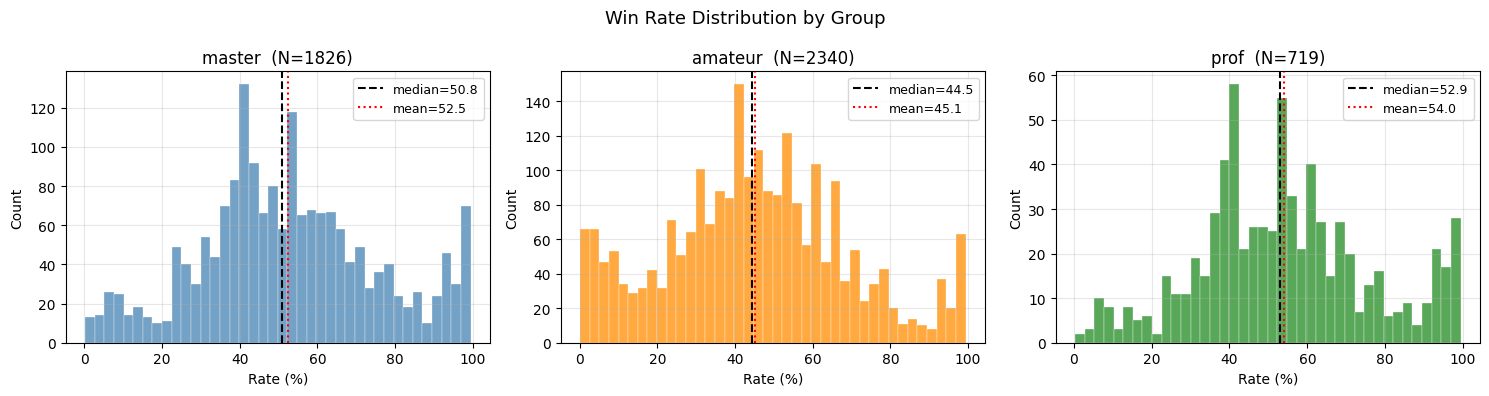

In [3]:
# ── Rate 分布視覺化 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, g in enumerate(GROUPS):
    r = df_trials[df_trials['Group'] == g]['Rate'].dropna()
    ax = axes[col]
    ax.hist(r, bins=40, color=COLORS[g], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(r.median(), color='black', linestyle='--', lw=1.5, label=f'median={r.median():.1f}')
    ax.axvline(r.mean(),   color='red',   linestyle=':',  lw=1.5, label=f'mean={r.mean():.1f}')
    ax.set_title(f'{g}  (N={len(r)})', fontsize=12)
    ax.set_xlabel('Rate (%)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Win Rate Distribution by Group', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\winrate_predict\rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── 確認 Rate 是 trial-level 還是 subject-level ──
# 如果同一個 subject 所有 trial 的 Rate 都一樣 → subject-level 固定值
# 如果每個 trial 的 Rate 不同 → trial-level 動態值

print('=== 各 Subject 的 Rate 唯一值數量 ===')
for g in GROUPS:
    df_g = df_trials[df_trials['Group'] == g].dropna(subset=['Rate'])
    print(f'\n[{g}]')
    for sub, grp in df_g.groupby('SubjectID'):
        n_unique = grp['Rate'].nunique()
        vals = sorted(grp['Rate'].unique())
        print(f'  {sub}: {n_unique} 個唯一值  {vals[:5]}{" ..." if n_unique > 5 else ""}')

=== 各 Subject 的 Rate 唯一值數量 ===

[master]
  sub-52: 83 個唯一值  [np.float64(0.2), np.float64(1.1), np.float64(4.3), np.float64(7.1), np.float64(8.8)] ...
  sub-55: 84 個唯一值  [np.float64(4.9), np.float64(7.5), np.float64(9.1), np.float64(10.9), np.float64(11.6)] ...
  sub-56: 87 個唯一值  [np.float64(7.9), np.float64(9.1), np.float64(10.6), np.float64(12.5), np.float64(14.0)] ...
  sub-57: 87 個唯一值  [np.float64(0.2), np.float64(1.2), np.float64(5.0), np.float64(5.8), np.float64(6.8)] ...
  sub-58: 84 個唯一值  [np.float64(5.8), np.float64(7.9), np.float64(22.9), np.float64(23.0), np.float64(23.6)] ...
  sub-59: 85 個唯一值  [np.float64(1.0), np.float64(7.5), np.float64(8.9), np.float64(13.4), np.float64(15.4)] ...
  sub-60: 80 個唯一值  [np.float64(5.1), np.float64(10.8), np.float64(12.9), np.float64(16.7), np.float64(19.8)] ...
  sub-61: 87 個唯一值  [np.float64(5.8), np.float64(8.6), np.float64(10.3), np.float64(13.9), np.float64(14.2)] ...
  sub-63: 85 個唯一值  [np.float64(0.3), np.float64(2.1), np.float64(9.2),

In [5]:
# ── 前處理：建立 190 維特徵矩陣（同 RT1_ms 流程）──
# 先載入全部頻帶
dfs = {}
for band in BANDS:
    dfs[band] = pd.read_csv(f'{DATA_DIR}\\Original_{band}.csv')
print('載入完成')

def preprocess_group(dfs, group):
    band_feats = {}
    rate_ref = None

    for band in BANDS:
        df = dfs[band]
        df_g = df[(df['Group'] == group) &
                  (df['Channel'].isin(PARIETAL_CH))].copy()
        df_g['Rate'] = pd.to_numeric(df_g['Rate'], errors='coerce')

        # 移除 Rate 無效的 trial
        bad = df_g[df_g['Rate'].isna()][['SubjectID','Session','Epoch']].drop_duplicates()
        if len(bad):
            print(f'[{group}/{band}] 移除 {len(bad)} 筆無效 Rate trial')
            df_g = df_g[~df_g.set_index(['SubjectID','Session','Epoch']).index.isin(
                bad.set_index(['SubjectID','Session','Epoch']).index)]

        grp = df_g.groupby(['SubjectID','Session','Epoch'])
        avg = grp[TIME_COLS].mean()
        rate = grp['Rate'].first()

        # sum=1 標準化
        avg_norm = avg.div(avg.sum(axis=1), axis=0)
        avg_norm.columns = [f'{band}_{c}' for c in TIME_COLS]

        band_feats[band] = avg_norm
        if rate_ref is None:
            rate_ref = rate
        else:
            assert avg_norm.index.equals(rate_ref.index), f'{band} index 不一致'

    X = pd.concat([band_feats[b] for b in BANDS], axis=1)
    y = rate_ref.rename('Rate')
    print(f'[{group}] X={X.shape}  Rate 範圍: {y.min():.2f}~{y.max():.2f}')
    return X, y


X_master,  y_master  = preprocess_group(dfs, 'master')
X_amateur, y_amateur = preprocess_group(dfs, 'amateur')
X_prof,    y_prof    = preprocess_group(dfs, 'prof')

載入完成
[master/Alpha] 移除 31 筆無效 Rate trial
[master/Beta] 移除 31 筆無效 Rate trial
[master/Delta] 移除 31 筆無效 Rate trial
[master/Gamma] 移除 31 筆無效 Rate trial
[master/Theta] 移除 31 筆無效 Rate trial
[master] X=(1826, 190)  Rate 範圍: 0.20~99.40
[amateur/Alpha] 移除 120 筆無效 Rate trial
[amateur/Beta] 移除 120 筆無效 Rate trial
[amateur/Delta] 移除 120 筆無效 Rate trial
[amateur/Gamma] 移除 120 筆無效 Rate trial
[amateur/Theta] 移除 120 筆無效 Rate trial
[amateur] X=(2340, 190)  Rate 範圍: 0.10~99.40
[prof] X=(719, 190)  Rate 範圍: 0.30~99.40


In [6]:
# ── 儲存三個 group 的特徵 CSV ──
import os
out_dir = r'd:\Tseng\game_eeg\winrate_predict'

for (X, y, g) in [(X_master, y_master, 'master'),
                   (X_amateur, y_amateur, 'amateur'),
                   (X_prof, y_prof, 'prof')]:
    df_out = X.copy()
    df_out['Rate'] = y
    df_out = df_out.reset_index()
    path = os.path.join(out_dir, f'{g}_parietal_190d.csv')
    df_out.to_csv(path, index=False)
    print(f'已儲存: {path}  shape={df_out.shape}')

已儲存: d:\Tseng\game_eeg\winrate_predict\master_parietal_190d.csv  shape=(1826, 194)
已儲存: d:\Tseng\game_eeg\winrate_predict\amateur_parietal_190d.csv  shape=(2340, 194)
已儲存: d:\Tseng\game_eeg\winrate_predict\prof_parietal_190d.csv  shape=(719, 194)
